# Matching and Pauli Decompositions

This notebook compares Matching and Pauli Decompositions for CTQW.

In [13]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore", category=Warning)

import sys
sys.path.append(f"./../")

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator

from src.core import MultiEdgeGraph, MatchingDecomposition, PauliDecomposition
from src.utils import get_exact_evolution_operator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Commuting Example

Edges that form a complete bipartite graph - all matchings commute.

Graph: MultiEdgeGraph with 2 qubits, 4 edges: {('01', '11'), ('01', '10'), ('00', '11'), ('00', '10')}
Number of qubits: 2
Number of edges: 4
Hamming cost: 6
Average Hamming cost: 1.500


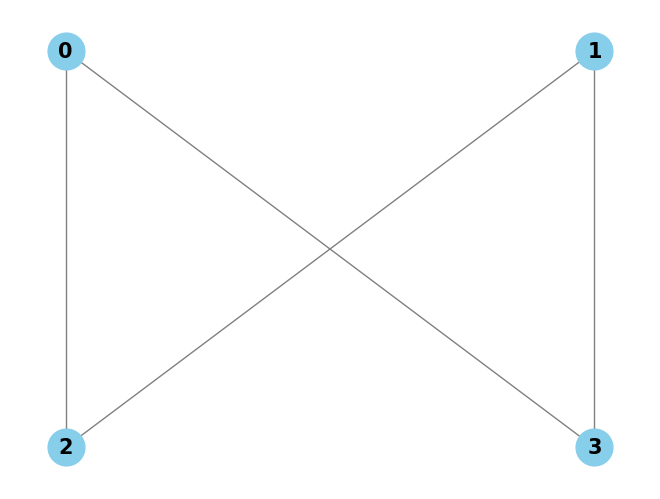

In [14]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11')}
delta_t = 0.1

# Create graph using new MultiEdgeGraph class
G = MultiEdgeGraph(edges)

print(f"Graph: {G}")
print(f"Number of qubits: {G.n_qubits}")
print(f"Number of edges: {G.n_edges}")
print(f"Hamming cost: {G.hamming_cost()}")
print(f"Average Hamming cost: {G.avg_hamming_cost():.3f}")

# Display graph
G.draw()

## Exact Evolution

In [15]:
# Get exact evolution operator
exact_op = get_exact_evolution_operator(delta_t, G.hamiltonian)
print(f"Exact operator shape: {exact_op.data.shape}")

Exact operator shape: (4, 4)


## Matching Decomposition

Number of matchings: 2
Matchings:
  Matching 1: {('10', '00'), ('01', '11')}
  Matching 2: {('01', '10'), ('11', '00')}

Matching circuit depth: 4


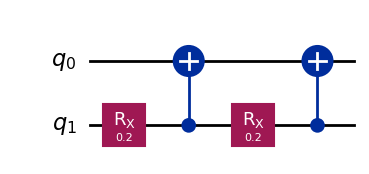

In [16]:
# Create matching decomposition
matching_decomp = MatchingDecomposition(G)

print(f"Number of matchings: {matching_decomp.num_matchings()}")
print(f"Matchings:")
for i, m in enumerate(matching_decomp.get_matchings()):
    print(f"  Matching {i+1}: {m}")

# Build circuit for single step
matching_qc = matching_decomp.build_circuit(n_steps=1, delta_t=delta_t)
print(f"\nMatching circuit depth: {matching_qc.depth()}")
matching_qc.draw('mpl')

In [17]:
# Compare with exact
matching_op = Operator(matching_qc)
matching_error = np.linalg.norm(matching_op.data - exact_op.data, ord=2)
print(f"Matching error (1 step): {matching_error:.6f}")

Matching error (1 step): 0.000000


## Pauli Decomposition

In [18]:
# Create Pauli decomposition
pauli_decomp = PauliDecomposition(G)

print(f"Number of Pauli terms: {len(pauli_decomp.pauli_terms)}")
print(f"Pauli terms:")
for pauli_str, coeff in pauli_decomp.pauli_terms[:10]:
    if abs(coeff) > 1e-10:
        print(f"  {pauli_str}: {coeff:.4f}")

# Build circuit for single step
pauli_qc = pauli_decomp.build_circuit(n_steps=1, delta_t=delta_t)
print(f"\nPauli circuit depth: {pauli_qc.depth()}")

Number of Pauli terms: 2
Pauli terms:
  XI: 1.0000
  XX: 1.0000

Pauli circuit depth: 2


In [19]:
# Compare with exact
pauli_op = Operator(pauli_qc)
pauli_error = np.linalg.norm(pauli_op.data - exact_op.data, ord=2)
print(f"Pauli error (1 step): {pauli_error:.6f}")

Pauli error (1 step): 0.000000


## Convergence Analysis

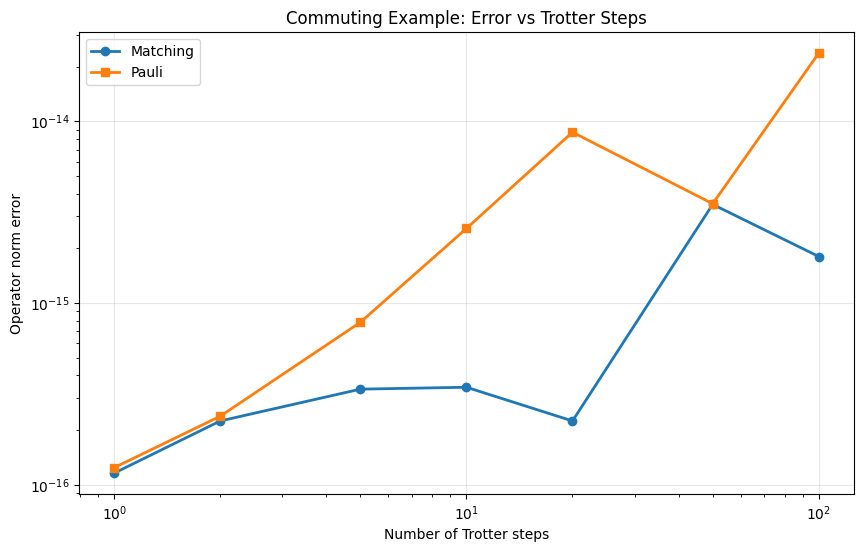

In [20]:
n_steps_list = [1, 2, 5, 10, 20, 50, 100]

matching_errors = []
pauli_errors = []

for n_steps in n_steps_list:
    # Matching
    qc = matching_decomp.build_circuit(n_steps=n_steps, delta_t=delta_t)
    op = Operator(qc)
    matching_errors.append(np.linalg.norm(op.data - exact_op.data, ord=2))
    
    # Pauli
    qc = pauli_decomp.build_circuit(n_steps=n_steps, delta_t=delta_t)
    op = Operator(qc)
    pauli_errors.append(np.linalg.norm(op.data - exact_op.data, ord=2))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(n_steps_list, matching_errors, 'o-', label='Matching', linewidth=2)
ax.loglog(n_steps_list, pauli_errors, 's-', label='Pauli', linewidth=2)
ax.set_xlabel('Number of Trotter steps')
ax.set_ylabel('Operator norm error')
ax.set_title('Commuting Example: Error vs Trotter Steps')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Non-Commuting Example

Edges that do not form a complete bipartite graph - terms do not commute.

Graph: MultiEdgeGraph with 2 qubits, 5 edges: {('01', '11'), ('01', '10'), ('00', '11'), ('00', '01'), ('00', '10')}
Number of qubits: 2
Number of edges: 5


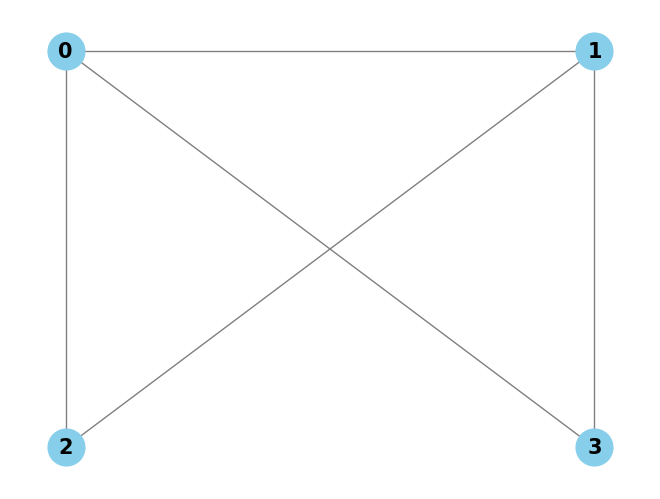

In [21]:
edges = {('00', '01'), ('00', '11'), ('01', '10'), ('00', '10'), ('01', '11')}
delta_t = 0.1

# Create graph
G = MultiEdgeGraph(edges)

print(f"Graph: {G}")
print(f"Number of qubits: {G.n_qubits}")
print(f"Number of edges: {G.n_edges}")

G.draw()

In [22]:
# Exact evolution
exact_op = get_exact_evolution_operator(delta_t, G.hamiltonian)

# Matching decomposition
matching_decomp = MatchingDecomposition(G)
print(f"Number of matchings: {matching_decomp.num_matchings()}")

# Pauli decomposition
pauli_decomp = PauliDecomposition(G)
print(f"Number of Pauli terms: {len(pauli_decomp.pauli_terms)}")

Number of matchings: 3
Number of Pauli terms: 4


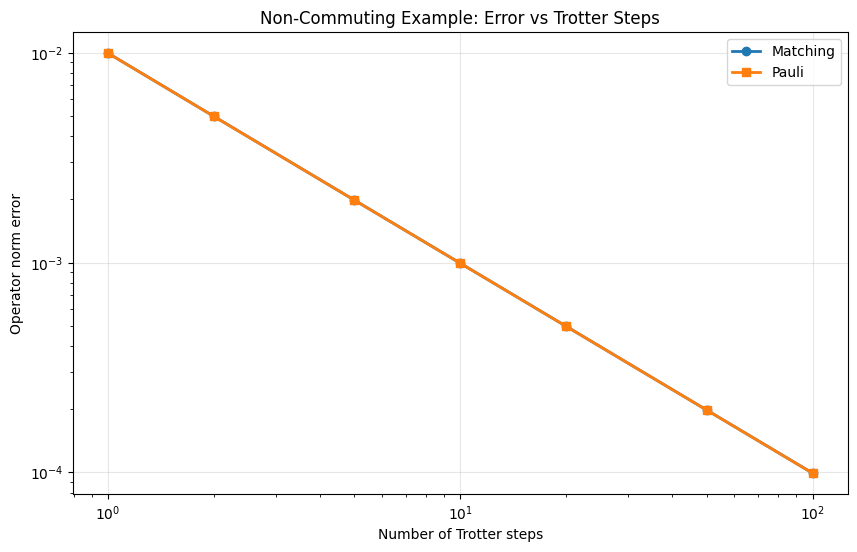

In [23]:
n_steps_list = [1, 2, 5, 10, 20, 50, 100]

matching_errors = []
pauli_errors = []

for n_steps in n_steps_list:
    # Matching
    qc = matching_decomp.build_circuit(n_steps=n_steps, delta_t=delta_t)
    op = Operator(qc)
    matching_errors.append(np.linalg.norm(op.data - exact_op.data, ord=2))
    
    # Pauli
    qc = pauli_decomp.build_circuit(n_steps=n_steps, delta_t=delta_t)
    op = Operator(qc)
    pauli_errors.append(np.linalg.norm(op.data - exact_op.data, ord=2))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(n_steps_list, matching_errors, 'o-', label='Matching', linewidth=2)
ax.loglog(n_steps_list, pauli_errors, 's-', label='Pauli', linewidth=2)
ax.set_xlabel('Number of Trotter steps')
ax.set_ylabel('Operator norm error')
ax.set_title('Non-Commuting Example: Error vs Trotter Steps')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Gate Count Comparison

In [24]:
def count_gates(qc):
    """Count gates after transpilation."""
    transpiled = transpile(qc, basis_gates=['u3', 'cx'], optimization_level=3)
    ops = transpiled.count_ops()
    return ops.get('cx', 0), ops.get('u3', 0)

print("Gate counts (CX/U3) for non-commuting example:")
print("n_steps | Matching | Pauli")
print("-" * 40)

for n_steps in [1, 10, 50]:
    m_qc = matching_decomp.build_circuit(n_steps=n_steps, delta_t=delta_t)
    p_qc = pauli_decomp.build_circuit(n_steps=n_steps, delta_t=delta_t)
    
    m_cx, m_u3 = count_gates(m_qc)
    p_cx, p_u3 = count_gates(p_qc)
    
    print(f"{n_steps:7d} | {m_cx:3d}/{m_u3:3d}   | {p_cx:3d}/{p_u3:3d}")

Gate counts (CX/U3) for non-commuting example:
n_steps | Matching | Pauli
----------------------------------------
      1 |   2/  6   |   2/  6
     10 |   2/  6   |   2/  6
     50 |   2/  6   |   2/  6
